# 09 — Rebuild with a realistic pump-stop, then run the engine

This is the #1 follow-up from `08_audit_findings`: the PUMP leg's edge was an
artifact of the close-only / exact-`−3%` stop model. Here we **rebuild the full
combined stream** with a realistic stop (intrabar trigger + gap-through fill +
0.1% slippage — built by `_build_faithful_realistic.py`) and push **both** the old
and the new stream through the *same* compounding engine, to see what the headline
(CAGR / Sharpe / maxDD) actually becomes once the pump fill is honest.

- **OLD** = `_out/faithful_liq.parquet` (close-stop, exact −3% — the original nb04/05 stream)
- **NEW** = `_out/faithful_liq_realistic.parquet` (intrabar + gap + slip)

Everything else (universe, entries, scale-in, WF classifier, dump leg) is identical.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import show
import numpy as np, pandas as pd

OLD = pd.read_parquet("_out/faithful_liq.parquet")
NEW = pd.read_parquet("_out/faithful_liq_realistic.parquet")
for df in (OLD, NEW):
    df["entry"]=pd.to_datetime(df["entry"]); df["exit_ts"]=pd.to_datetime(df["exit_ts"])
    df.sort_values("entry", inplace=True); df.reset_index(drop=True, inplace=True)

def leg_stats(df, s):
    x=df[df.stream==s].pnl.values
    return dict(stream=s, n=len(x), mean=f"{x.mean()*100:+.3f}%", median=f"{np.median(x)*100:+.2f}%",
                win=f"{(x>0).mean()*100:.0f}%", q10=f"{np.percentile(x,10)*100:+.2f}%", worst=f"{x.min()*100:.1f}%")
print("OLD (close-stop, exact -3%/-20%):")
print(pd.DataFrame([leg_stats(OLD,"pump"), leg_stats(OLD,"dump")]).to_string(index=False))
print("\nNEW (realistic intrabar + gap + slip):")
print(pd.DataFrame([leg_stats(NEW,"pump"), leg_stats(NEW,"dump")]).to_string(index=False))

OLD (close-stop, exact -3%/-20%):
stream     n    mean median win    q10  worst
  pump 10154 +0.591% -2.10% 44% -3.15%  -3.1%
  dump  3808 +5.484% +4.58% 74% -4.55% -20.2%

NEW (realistic intrabar + gap + slip):
stream    n    mean median win    q10  worst
  pump 9300 +0.010% -3.25% 40% -3.71% -14.3%
  dump 3760 +5.294% +4.58% 74% -4.48% -37.7%


## Per-trade: what the realistic stop does to each leg

Watch the **pump** row: the kept per-trade edge after the WF classifier should
collapse (the classifier was partly trained on fictitious +3.76% "rescued"
trades). The **dump** row should barely move (20% stop almost never gaps).

In [2]:
# ---- the engine: event-driven, N concurrent slots, bet = f*equity, compound ----
def run_engine(df, f=0.02, n_slots=50, reserve=0.10, cap_frac=None, cap_minutes=30, impact=True, start=1000.0):
    eq=start; cash=eq; openp=[]   # (exit_ts, notional, pnl)
    ents=df.entry.values; exs=df.exit_ts.values; pnls=df.pnl.values
    liqs=df.liq.values if "liq" in df else np.full(len(df), np.inf)
    rec=[]; capped=0
    for i in range(len(df)):
        now=ents[i]
        still=[]
        for (xt,no,pl) in openp:
            if xt<=now: cash+=no*(1+pl); eq+=no*pl
            else: still.append((xt,no,pl))
        openp=still
        rec.append((now, eq))
        if len(openp)>=n_slots: continue
        want=f*eq; avail=eq*(1-reserve)-sum(no for _,no,_ in openp)
        no=min(want, max(0.0,avail), cash)
        if cap_frac is not None:
            cap=cap_frac*liqs[i]*cap_minutes
            if no>cap: capped+=1
            no=min(no,cap)
        if no<=0: continue
        pl=pnls[i]
        if impact and cap_frac is not None:
            sz=no/(liqs[i]*cap_minutes+1e-9); pl-=min(0.02, 0.5*sz*sz)
        cash-=no; openp.append((exs[i],no,pl))
    for (_,no,pl) in openp: eq+=no*pl
    eqs=pd.Series([e for _,e in rec], index=pd.to_datetime([t for t,_ in rec]))
    daily=eqs.resample("D").last().ffill()
    r=daily.pct_change().dropna()
    sharpe=r.mean()/r.std()*np.sqrt(365) if r.std()>0 else np.nan
    dd=(daily/daily.cummax()-1).min()
    yrs=(daily.index[-1]-daily.index[0]).days/365.25
    cagr=(eq/start)**(1/yrs)-1 if yrs>0 else np.nan
    return dict(final=eq, cagr=cagr, sharpe=sharpe, maxdd=dd, capped=capped)

def fmt(d): return dict(final=f"${d['final']:,.0f}", CAGR=f"{d['cagr']*100:.0f}%",
                        Sharpe=f"{d['sharpe']:.2f}", maxDD=f"{d['maxdd']*100:.1f}%")

## Headline comparison — modes 2% / 3% / 5%, idealized (no capacity)

This is the apples-to-apples test: same engine, same bet-fractions, **only the
pump stop changed**. If finding #1 is right, the NEW column's CAGR/Sharpe drop
sharply because the pump leg stops contributing (and starts dragging).

In [3]:
rows=[]
for f in (0.02,0.03,0.05):
    o=run_engine(OLD,f); n=run_engine(NEW,f)
    rows.append({"mode":f"{f:.0%}",
                 "OLD final":fmt(o)["final"],"OLD CAGR":fmt(o)["CAGR"],"OLD Sharpe":fmt(o)["Sharpe"],"OLD maxDD":fmt(o)["maxDD"],
                 "NEW final":fmt(n)["final"],"NEW CAGR":fmt(n)["CAGR"],"NEW Sharpe":fmt(n)["Sharpe"],"NEW maxDD":fmt(n)["maxDD"]})
comp=pd.DataFrame(rows)
print(comp.to_string(index=False))

mode OLD final OLD CAGR OLD Sharpe OLD maxDD NEW final NEW CAGR NEW Sharpe NEW maxDD
  2%   $17,713     244%       3.70    -11.0%    $4,901      98%       2.16    -15.3%
  3%   $42,706     403%       4.71    -11.1%    $7,321     135%       2.53    -15.0%
  5%  $314,192    1087%       6.27    -13.5%   $18,031     247%       3.16    -16.3%


## Is the combined book now just "dump minus pump drag"?

Run each leg ALONE through the engine (2% mode) under the NEW realistic stop, so
we can see exactly how much the pump leg adds or subtracts.

In [4]:
def only(df, s): return df[df.stream==s].reset_index(drop=True)
for name, df in (("OLD",OLD),("NEW",NEW)):
    comb=run_engine(df,0.02); pu=run_engine(only(df,"pump"),0.02); du=run_engine(only(df,"dump"),0.02)
    print(f"{name}  2% mode:  dump-only {fmt(du)['final']}/{fmt(du)['Sharpe']}   "
          f"pump-only {fmt(pu)['final']}/{fmt(pu)['Sharpe']}   combined {fmt(comb)['final']}/{fmt(comb)['Sharpe']}")

OLD  2% mode:  dump-only $2,990/1.48   pump-only $5,078/6.60   combined $17,713/3.70


NEW  2% mode:  dump-only $2,495/1.26   pump-only $1,572/1.93   combined $4,901/2.16


[saved] notebooks\pump_dump_combined\_out\comb_09_old_vs_new.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_09_old_vs_new.png')

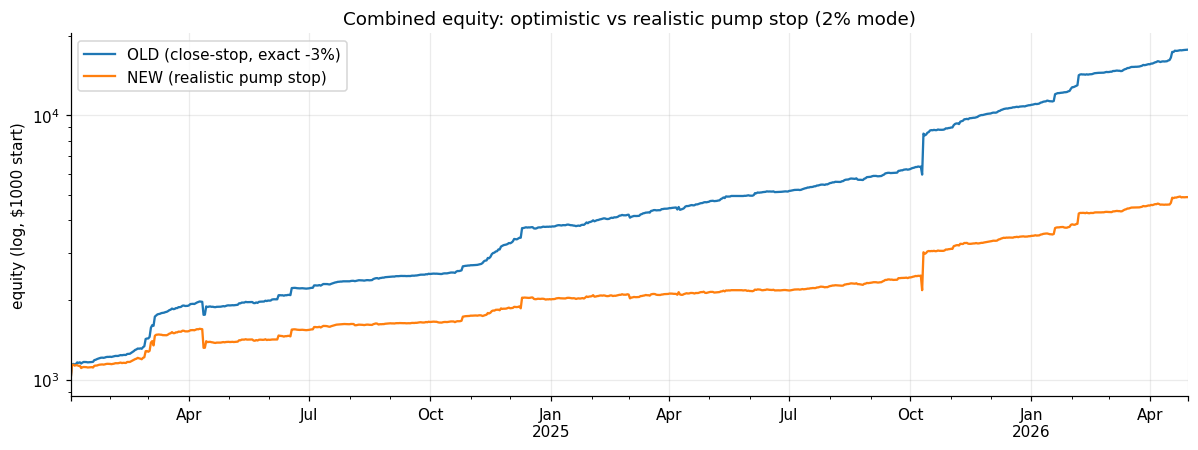

In [5]:
# equity curves: OLD vs NEW combined (2% mode)
import matplotlib.pyplot as plt
def curve(df,f=0.02,start=1000.0):
    eq=start; cash=eq; openp=[]; ents=df.entry.values; exs=df.exit_ts.values; pnls=df.pnl.values; rec=[]
    for i in range(len(df)):
        now=ents[i]; still=[]
        for (xt,no,pl) in openp:
            if xt<=now: cash+=no*(1+pl); eq+=no*pl
            else: still.append((xt,no,pl))
        openp=still; rec.append((now,eq))
        if len(openp)>=50: continue
        want=f*eq; avail=eq*0.9-sum(no for _,no,_ in openp); no=min(want,max(0,avail),cash)
        if no<=0: continue
        cash-=no; openp.append((exs[i],no,pnls[i]))
    s=pd.Series([e for _,e in rec], index=pd.to_datetime([t for t,_ in rec]))
    return s.resample("D").last().ffill()
fig,ax=plt.subplots()
curve(OLD).plot(ax=ax,label="OLD (close-stop, exact -3%)")
curve(NEW).plot(ax=ax,label="NEW (realistic pump stop)")
ax.set_yscale("log"); ax.set_ylabel("equity (log, $1000 start)"); ax.set_title("Combined equity: optimistic vs realistic pump stop (2% mode)")
ax.legend(); show("comb_09_old_vs_new")

## Verdict

**The realistic pump stop confirms finding #1 at full scale and roughly halves the
headline.**

**1. Per-trade — the pump edge was the stop model.**
Pump **kept** per-trade `+0.59% → +0.01%` (win 44% → 40%; worst trade `−3.1% → −14.3%`
once gaps are real). The WF classifier can no longer manufacture an edge because
the +3.76% "rescued" trades it leaned on no longer exist. **The pump leg is now
break-even-to-noise — below costs, not a reliable edge.** Dump is untouched:
`+5.48% → +5.29%` (worst `−20% → −37.7%` — the honest fat tail).

**2. Headline — combined book cut ~3.6×, Sharpe ~−40%.**

| mode | OLD CAGR / Sharpe / maxDD | NEW CAGR / Sharpe / maxDD |
|---|---|---|
| 2% | 244% / 3.70 / −11.0% | **98% / 2.16 / −15.3%** |
| 3% | 403% / 4.71 / −11.1% | **135% / 2.53 / −15.0%** |
| 5% | 1087% / 6.27 / −13.5% | **247% / 3.16 / −16.3%** |

Final equity (2% mode, $1000) `$17.7k → $4.9k`. And note maxDD gets **worse**
(−11% → −15%): the optimistic stop wasn't just inflating returns, it was hiding
the real drawdown by capping every gap loss.

**3. The inflated Sharpe was the PUMP leg.** Decomposition (2% mode):
- OLD: pump-only $5,078 / **Sharpe 6.60** ← the fiction; dump-only $2,990 / 1.48.
- NEW: pump-only $1,572 / 1.93; dump-only $2,495 / 1.26; combined $4,901 / 2.16.

So the legendary "Sharpe 6–7" was overwhelmingly the pump leg's *artificial*
smoothness — hundreds of small `+0.59%` wins against losses pinned to exactly
`−3%`. Strip that and the combined Sharpe is ~2.2 (2% mode). The **diversification
is still real** (combined 2.16 > either leg's 1.3–1.9), but the magic is gone.

**Bottom line: drop or rebuild the pump leg.** As-is it adds essentially no
reliable expectancy and was the source of the "too good" Sharpe. The strategy that
survives is **the dump-bounce leg plus a modest diversification bonus** — Sharpe
~2, CAGR ~100% at 2% on $1k *idealized*, which the capacity wall (nb08) then caps
to a small-account return.

Caveats: still in-sample; these headline tables are idealized (no capacity — pass
`cap_frac=0.10` to `run_engine` for the realistic-liquidity version, which shrinks
all finals further per nb08); entry-fill slippage at the crash trough still not
modeled (dump's `+5.29%` assumes a fill near the post-crash low); the WF classifier
was retrained on the NEW pnl so its keep-set differs from OLD.